vmax: 316.1180679441437


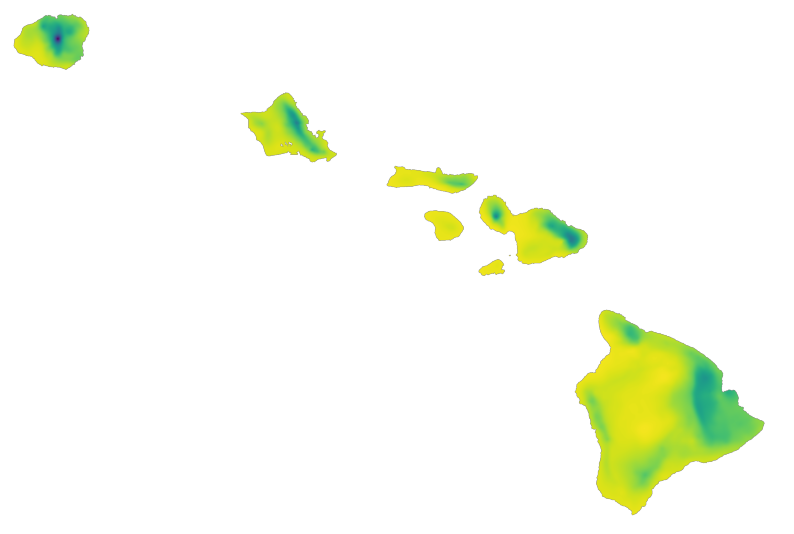

In [ ]:
#Save PNG of annual rainfall aggregated for website display
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

out_png = "../../public/climate-summary/annual_rainfall_2025_agg.png"

with rasterio.open("annual_rainfall_2025_agg.tif") as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds  

masked = np.ma.masked_where(data == nodata, data) / 25.4

vmax = np.nanmax(masked)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    masked,
    cmap = 'viridis_r',
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    vmin=0,
    vmax=vmax,
)
print(f"vmax: {vmax}")
ax.set_axis_off()  # removes ticks + border/frame
# cbar = fig.colorbar(im, ax=ax)
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()


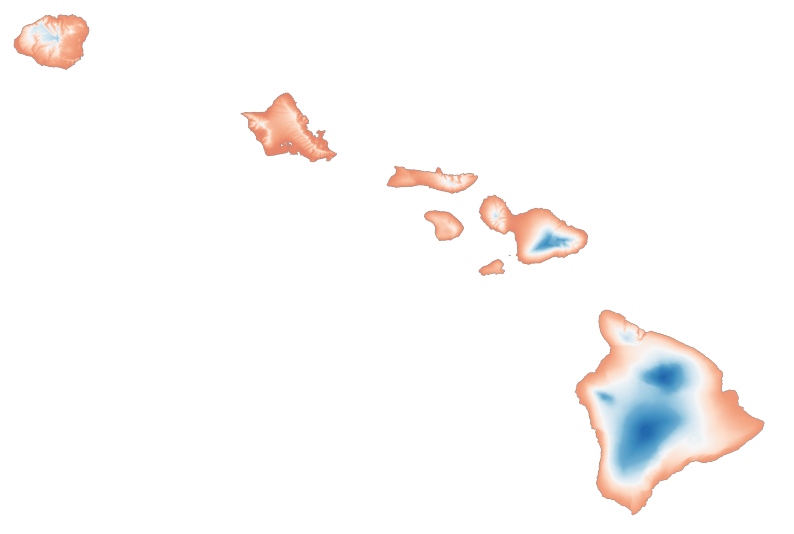

In [ ]:
#Save PNG of annual tmean aggregated for website 
out_png = "../../public/climate-summary/annual_tmean_2025_agg.png"

with rasterio.open("annual_tmean_2025_agg.tif") as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    bounds = src.bounds  

masked = np.ma.masked_where(data == nodata, data)*9/5 + 32  # C to F


fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    masked,
    cmap = 'RdBu_r',
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    vmin = 40,
    vmax = 90,
)
ax.set_axis_off()  # removes ticks + border/frame

# cbar = fig.colorbar(im)
# cbar.set_label("Mean temperature (deg F)")

# print(f"Vabs: {vabs}")
fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()




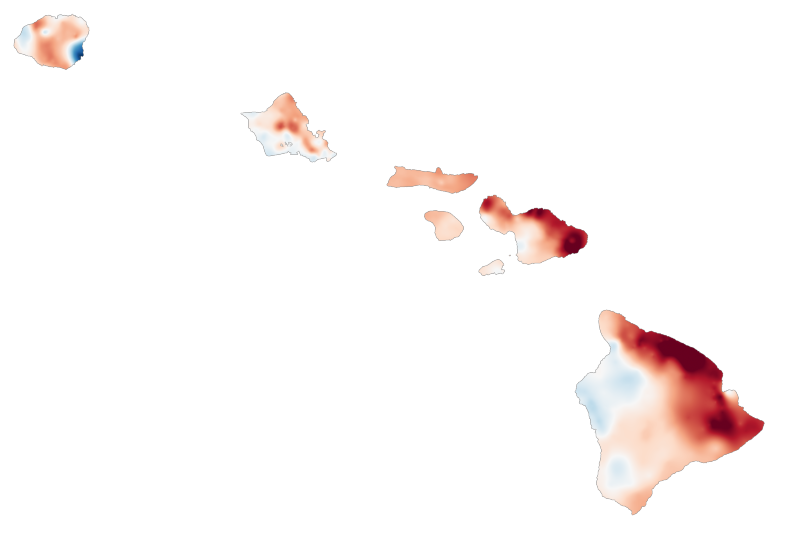

In [ ]:
#Categorical drought/wetness map for December SPI 12-month 
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -2, "#730000", "D4 Exceptional Drought"),
    (-2,   -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,   -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,   -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,    0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,    0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,    1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,    1.6, "#0066CC", "W2 Severely Wet"),
    ( 1.6,    2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,  np.inf, "#001933", "W4 Exceptionally Wet"),
]


with rasterio.open(f"spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

# cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
# cbar.set_ticks(range(len(colors)))
# cbar.set_ticklabels(labels)
# cbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('../../public/climate-summary/spi12.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


In [ ]:
#SPI with legend for report

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from rasterio.plot import plotting_extent

thresholds = [
    (-np.inf, -2, "#730000", "D4 Exceptional Drought"),
    (-2,   -1.6, "#FF0000", "D3 Extreme Drought"),
    (-1.6,   -1.3, "#FF9900", "D2 Severe Drought"),
    (-1.3,   -0.8, "#FFD37F", "D1 Moderate Drought"),
    (-0.8,    -0.5, "#FFFF00", "D0 Abnormally Dry"),
    (-0.5,    0.5, "#FFFFFF", "Near Normal"),
    ( 0.5,    0.8, "#99CCFF", "W0 Abnormally Wet"),
    ( 0.8,    1.3, "#0066CC", "W1 Moderately Wet"),
    ( 1.3,    1.6, "#0066CC", "W2 Severely Wet"),
    ( 1.6,    2.0, "#003366", "W3 Extremely Wet"),
    ( 2.0,  np.inf, "#001933", "W4 Exceptionally Wet"),
]
coast_path = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/public/shapefiles/Coastline.shp"


with rasterio.open(f"spi_month_timescale012_statewide_data_map_2025_12.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata
    extent = rasterio.plot.plotting_extent(src)  # (left, right, bottom, top)
    raster_crs = src.crs

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)
coast = gpd.read_file(coast_path)
if raster_crs is not None and coast.crs is not None and coast.crs != raster_crs:
    coast = coast.to_crs(raster_crs)
fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    categorical_masked,
    cmap=cmap,
    norm=norm,
    extent=extent,             # align raster with geodata
    interpolation="nearest",   # avoid halos
    resample=False
)


coast.boundary.plot(
    ax=ax,
    color="#6e6e6e",
    linewidth=0.5,
    alpha=0.9
)

plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
cbar.ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../../public/climate-summary/pubs/Figure5.png', dpi=600, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()



In [ ]:
# -- Rainfall category PNG for website display --
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -70, "#4b0000", "< -70%"),
    (-70,   -50, "#7f0000", "-70% to -50%"),
    (-50,   -30, "#c00000", "-50% to -30%"),
    (-30,   -10, "#ff5a1f", "-30% to -10%"),
    (-10,    10, "#ffffff", "-10% to 10%"),
    ( 10,    30, "#cfefff", "10% to 30%"),
    ( 30,    50, "#7fc3ff", "30% to 50%"),
    ( 50,    70, "#2f7dff", "50% to 70%"),
    ( 70,  np.inf, "#001a4d", "> 70%"),
]

with rasterio.open(f"annual_rainfall_2025_pdiff.tif") as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
# with rasterio.open(f"../public/tifs/rf_pdiff_cat_0{month}.tif", "w", **profile) as dst:
#     dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

# cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
# cbar.set_ticks(range(len(colors)))
# cbar.set_ticklabels(labels)
# cbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('../../public/climate-summary/annual_rainfall_2025_pdiff.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


In [ ]:
# Rainfall category map for report
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from rasterio.plot import plotting_extent


# Save with legend for report + coastline outline

thresholds = [
    (-np.inf, -70, "#4b0000", "< -70%"),
    (-70,   -50, "#7f0000", "-70% to -50%"),
    (-50,   -30, "#c00000", "-50% to -30%"),
    (-30,   -10, "#ff5a1f", "-30% to -10%"),
    (-10,    10, "#ffffff", "-10% to 10%"),
    ( 10,    30, "#cfefff", "10% to 30%"),
    ( 30,    50, "#7fc3ff", "30% to 50%"),
    ( 50,    70, "#2f7dff", "50% to 70%"),
    ( 70,  np.inf, "#001a4d", "> 70%"),
]

tif_path = "annual_rainfall_2025_pdiff.tif"
coast_path = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/public/shapefiles/Coastline.shp"
out_png = "../../public/climate-summary/pubs/Figure1.png"

with rasterio.open(tif_path) as src:
    data = src.read(1)
    nodata = src.nodata
    extent = rasterio.plot.plotting_extent(src)  # (left, right, bottom, top)
    raster_crs = src.crs

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

categorical_masked = np.ma.masked_where(categorical == 255, categorical)

# Read + reproject coastline to raster CRS
coast = gpd.read_file(coast_path)
if raster_crs is not None and coast.crs is not None and coast.crs != raster_crs:
    coast = coast.to_crs(raster_crs)

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    categorical_masked,
    cmap=cmap,
    norm=norm,
    extent=extent,             # align raster with geodata
    interpolation="nearest",   # avoid halos
    resample=False
)

# Gray coastline outline (control width here)
coast.boundary.plot(
    ax=ax,
    color="#6e6e6e",
    linewidth=0.5,
    alpha=0.9
)

ax.set_axis_off()

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)

fig.tight_layout()
fig.savefig(out_png, dpi=600, bbox_inches="tight", pad_inches=0.1, transparent=True)
plt.show()


In [ ]:
#Temperature category map for website
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Clean °F anomaly thresholds (ΔF). Data is still °C anomalies.
# 5 cold bins + neutral + 5 warm bins
thresholds_f = [
    (-np.inf, -2.25, "#001933", "< -2.25°F"),
    (-2.25,   -1.75, "#003d80", "-2.25 to -1.75°F"),
    (-1.75,   -1.25, "#0066CC", "-1.75 to -1.25°F"),
    (-1.25,   -0.75, "#66a3ff", "-1.25 to -0.75°F"),
    (-0.75,   -0.25, "#cfe8ff", "-0.75 to -0.25°F"),
    (-0.25,    0.25, "#FFFFFF", "-0.25 to 0.25°F"),
    ( 0.25,    0.75, "#ffe1c2", "0.25 to 0.75°F"),
    ( 0.75,    1.25, "#FF9900", "0.75 to 1.25°F"),
    ( 1.25,    1.75, "#FF4d00", "1.25 to 1.75°F"),
    ( 1.75,   2.25, "#FF0000", "1.75 to 2.25°F"),
    ( 2.25,  np.inf, "#730000", "> 2.25°F"),
]

# Convert °F anomaly edges to °C anomaly edges for classification (ΔC = ΔF / 1.8)
def f_to_c_anom(x):
    if np.isneginf(x) or np.isposinf(x):
        return x
    return x / 1.8

# Build classification thresholds in °C, but keep °F labels/colors
thresholds = [(f_to_c_anom(lo), f_to_c_anom(hi), color, label)
              for lo, hi, color, label in thresholds_f]

with rasterio.open("annual_tmean_2025_anomaly.tif") as src:
    data = src.read(1).astype("float32")
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)

categorical = np.full_like(data, 255, dtype=np.uint8)

# classify using °C edges derived from clean °F edges
for i, (low_c, high_c, _, _) in enumerate(thresholds):
    mask = (data > low_c) & (data <= high_c)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress="lzw", nodata=255)

# Plot with °F legend
colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

# cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
# cbar.set_ticks(range(len(colors)))
# cbar.set_ticklabels(labels)
# cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('../../public/climate-summary/annual_tmean_2025_anomaly.png', dpi=300, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()


In [ ]:
#Temperature category map for report
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from rasterio.plot import plotting_extent


# Clean °F anomaly thresholds (ΔF). Data is still °C anomalies.
# 5 cold bins + neutral + 5 warm bins
thresholds_f = [
    (-np.inf,   -1.75, "#003d80", "< to -1.75°F"),
    (-1.75,   -1.25, "#0066CC", "-1.75 to -1.25°F"),
    (-1.25,   -0.75, "#66a3ff", "-1.25 to -0.75°F"),
    (-0.75,   -0.25, "#cfe8ff", "-0.75 to -0.25°F"),
    (-0.25,    0.25, "#FFFFFF", "-0.25 to 0.25°F"),
    ( 0.25,    0.75, "#ffe1c2", "0.25 to 0.75°F"),
    ( 0.75,    1.25, "#FF9900", "0.75 to 1.25°F"),
    ( 1.25,    1.75, "#FF0000", "1.25 to 1.75°F"),
    ( 1.75,   np.inf, "#730000", ">1.75°F"),
]

coast_path = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/public/shapefiles/Coastline.shp"


# Convert °F anomaly edges to °C anomaly edges for classification (ΔC = ΔF / 1.8)
def f_to_c_anom(x):
    if np.isneginf(x) or np.isposinf(x):
        return x
    return x / 1.8

# Build classification thresholds in °C, but keep °F labels/colors
thresholds = [(f_to_c_anom(lo), f_to_c_anom(hi), color, label)
              for lo, hi, color, label in thresholds_f]

with rasterio.open("annual_tmean_2025_anomaly.tif") as src:
    data = src.read(1).astype("float32")
    profile = src.profile
    nodata = src.nodata
    extent = rasterio.plot.plotting_extent(src) 
    raster_crs = src.crs
data = np.where(data == nodata, np.nan, data)

categorical = np.full_like(data, 255, dtype=np.uint8)

coast = gpd.read_file(coast_path)
if raster_crs is not None and coast.crs is not None and coast.crs != raster_crs:
    coast = coast.to_crs(raster_crs)

# classify using °C edges derived from clean °F edges
for i, (low_c, high_c, _, _) in enumerate(thresholds):
    mask = (data > low_c) & (data <= high_c)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress="lzw", nodata=255)

# Plot with °F legend
colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)
fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    categorical_masked,
    cmap=cmap,
    norm=norm,
    extent=extent,             # align raster with geodata
    interpolation="nearest",   # avoid halos
    resample=False
)
plt.axis("off")

coast.boundary.plot(
    ax=ax,
    color="#6e6e6e",
    linewidth=0.5,
    alpha=0.9
)

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('../../public/climate-summary/pubs/Figure3.png', dpi=600, bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()
